In this example we will study the effect of R248Q of TP53 and inspect how residue preferences shift
at functionally important positions. We will do three things:
- mutate the wildtype TP53 at position 248
- obtain an MSA for both sequences using MMSeqs2
- create a residue histogram for each MSA at different positions

In [1]:
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from frankenmsa.align import MMSeqs2Colab
from frankenmsa.msa import MSA


/opt/anaconda3/envs/frankenfold/lib/python3.13/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /opt/anaconda3/envs/frankenfold/lib/python3.13/site-packages
  warnings.warn(


To mutate the TP53 sequence we could just use a string index operation, or we use the `replace_at` method of the `MSA` class to do it for us.

In [2]:
tp53_query = (
    "SQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGPDEAPRMPEAAPPVAPAPAAPTPAAPAP"
    "SWPLSSSVPSQKTYQGSYGFRLGFLHSGTAKSVTCTYSPALNKMFCQLAKTCPVQLWVDSTPPPGTRVRAMAIY"
    "KQSQHMTEVVRRCPHHERCSDSDGLAPPQHLIRVEGNLRVEYLDDRNTFRHSVVVPYEPPEVGSDCTTIHYNYM"
    "CNSSCMGGMNRRPILTIITLEDSSGNLLGRNSFEVRVCACPGRDRRTEEENLRKKGEPHHELPPGSTKRALPTST"
)

wt = MSA.from_sequences([tp53_query])
mut = wt.copy().replace_at(247, "Q") # remember python uses 0-based indexing, so position 248 is index 247

Then we can use the `MMSeqs2Colab` class to obtain a dataframe of sequences that align to our input queries. If we're using the `MSA`-wrapped versions we need to get the query-sequence as a string using the `query_` attribute (`query` would return an MSA-wrapped single-sequence).

In [3]:
mmseqs = MMSeqs2Colab(user_agent="frankenmsa-tutorials")

wt_msa_raw = mmseqs.align([wt.query_])
mut_msa_raw = mmseqs.align([mut.query_])

# we the re-wrap with MSA to remove dulicate sequences and filter out sequences with too many gaps
wt = MSA(wt_msa_raw).drop_duplicates().filter_gaps(0.4)
mut = MSA(mut_msa_raw).drop_duplicates().filter_gaps(0.4)

We can also look at the two MSAs using the `visualise` method

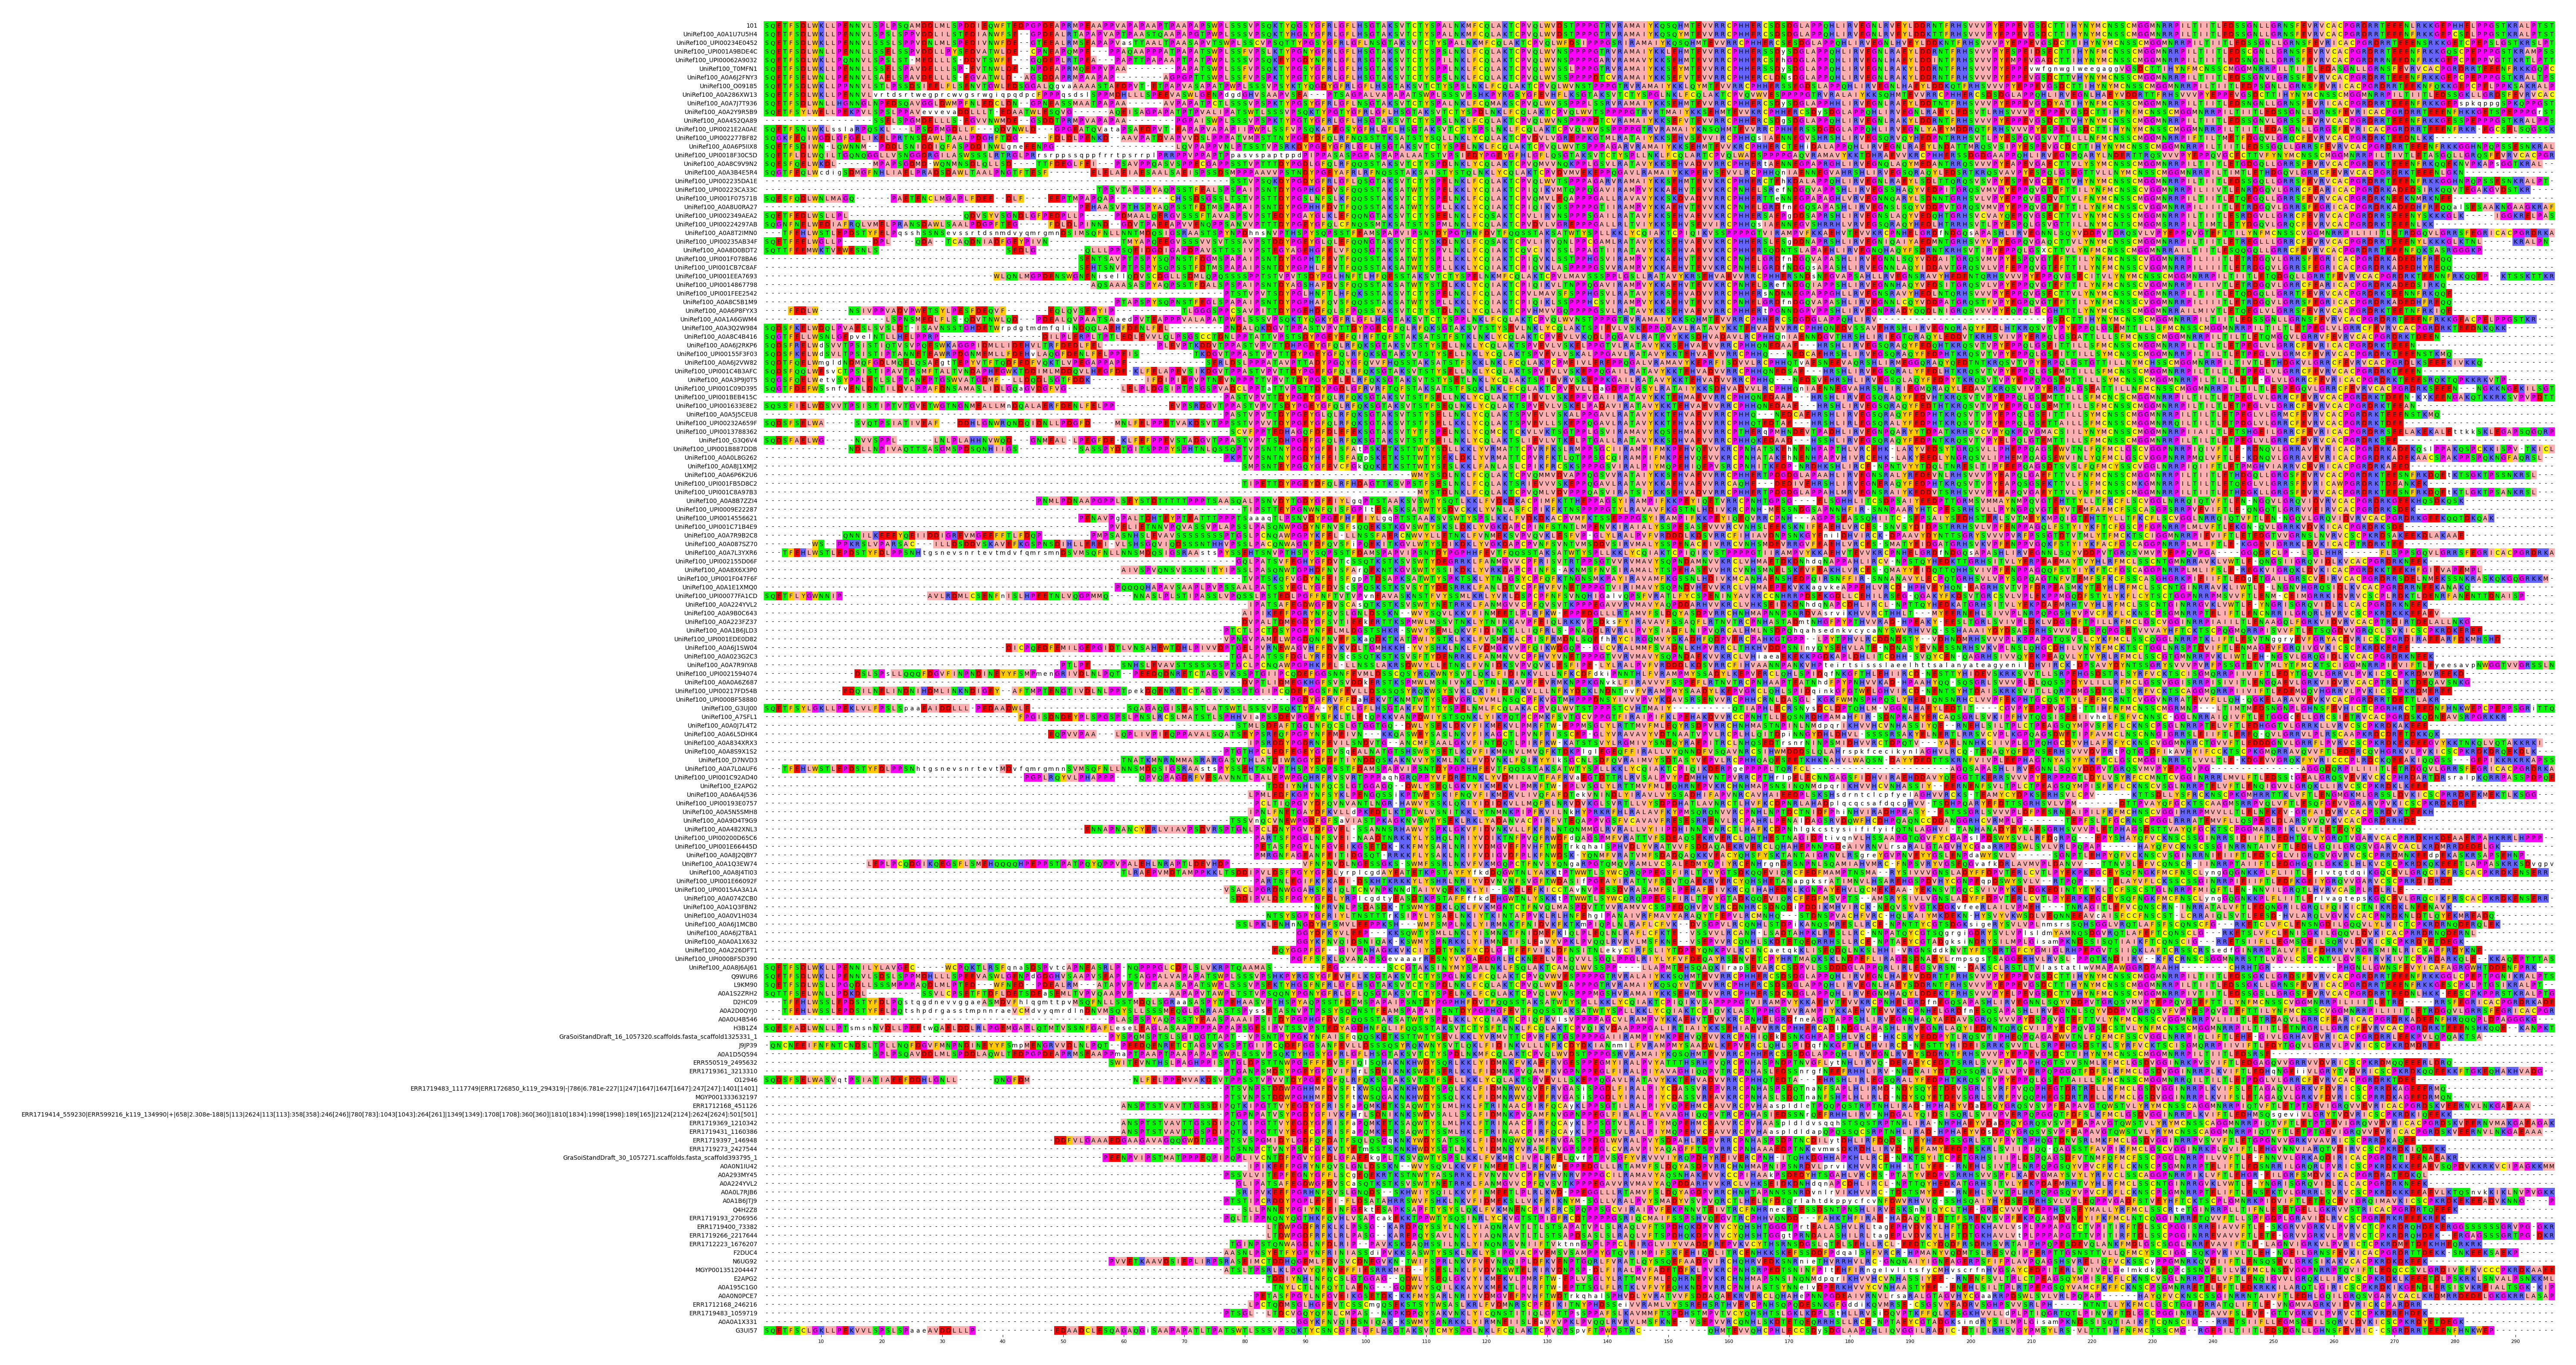

In [4]:
_ = wt.visualise()

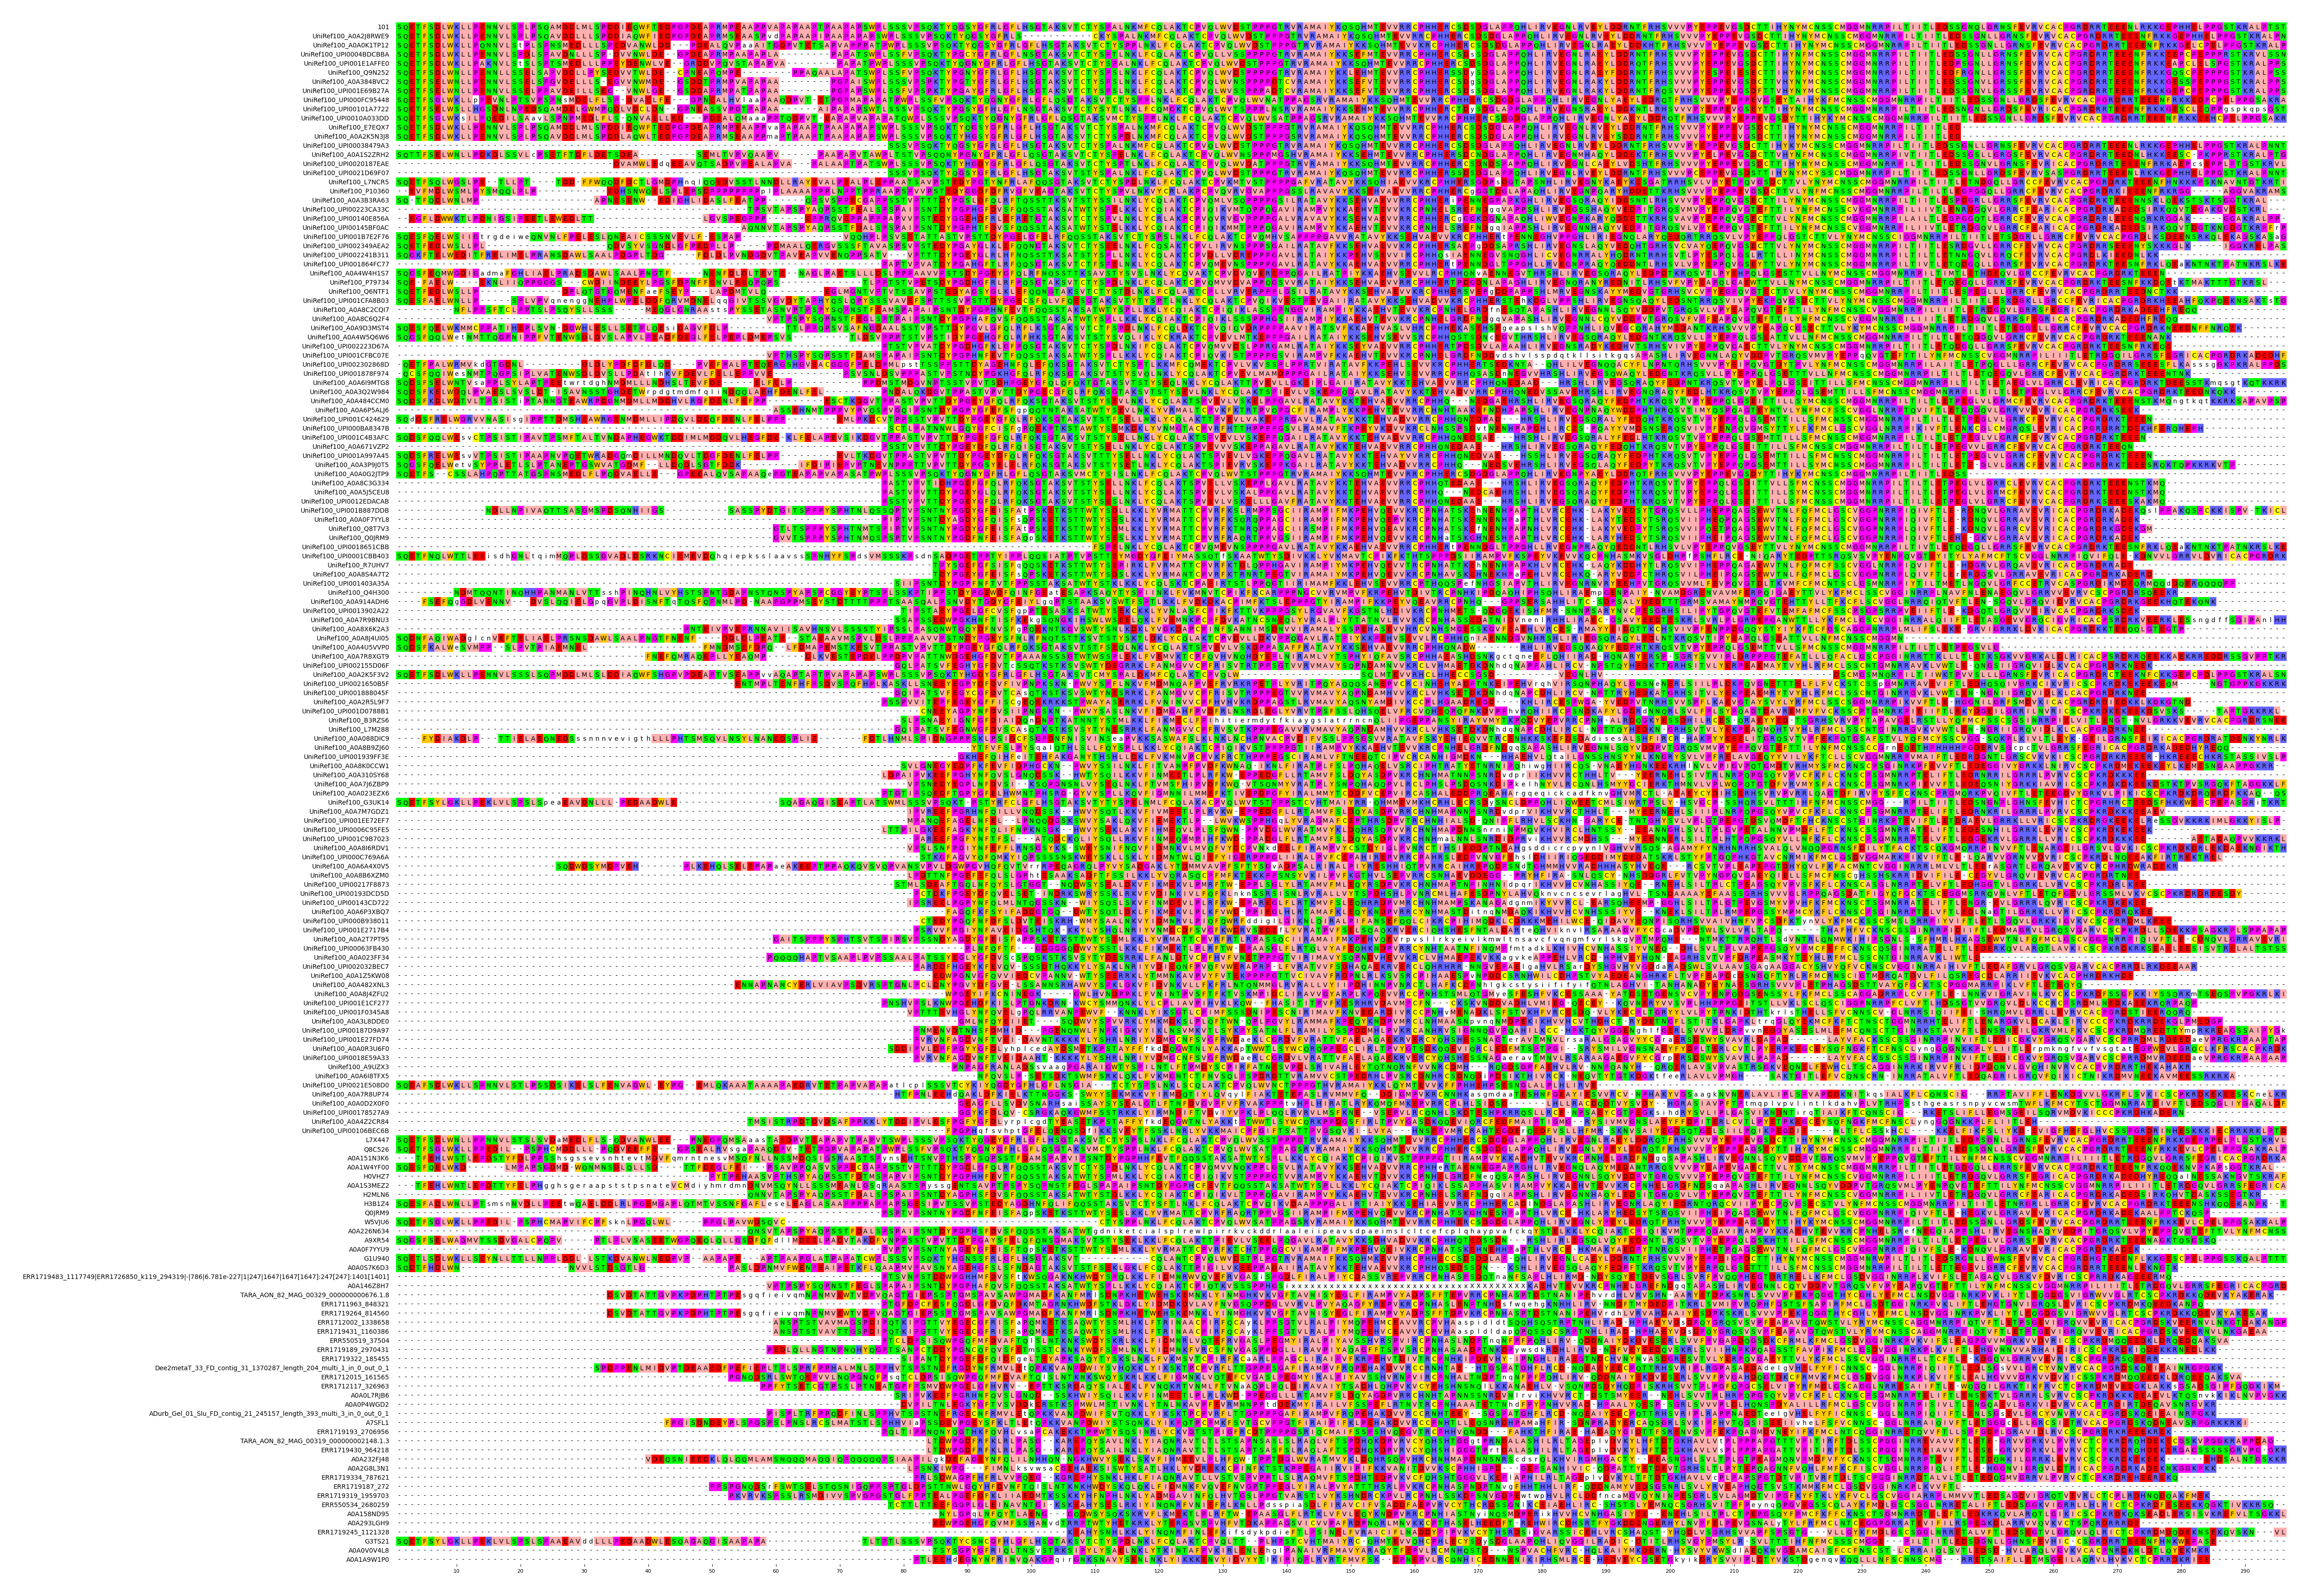

In [5]:
_ = mut.visualise()

With two working MSAs we can now compute a residue histogram. Known molecular hotspots of TP53 are positions R175, R248, and R273. Let's compute the histogram of aligned residues for these three positions. 

In [6]:
def residue_frequencies(msa: MSA, pos_0based: int, top_n: int = 8) -> pd.Series:
    residues = []
    for s in msa.df["sequence"]:
        if pos_0based < len(s):
            aa = s[pos_0based]
            if aa != "-":
                residues.append(aa)
    counts = Counter(residues)
    total = sum(counts.values()) or 1
    freq = {aa: c / total for aa, c in counts.items()}
    return pd.Series(freq).sort_values(ascending=False).head(top_n)

# canonical DNA-contact/hotspot positions in TP53 core domain
positions = {
    "R175 hotspot": 174,
    "R248 hotspot": 247,
    "R273 hotspot": 272,
}

# assemble the frequency tables for each hotspot.
position_freqs = {}
for label, pos in positions.items():
    wt_freq = residue_frequencies(wt, pos, top_n=6)
    mut_freq = residue_frequencies(mut, pos, top_n=6)
    position_freqs[label] = {"wt": wt_freq, "mut": mut_freq}

And now that we have frequency counts we can either tabulate or visualise them. Let's make a spider plot to end this example with.

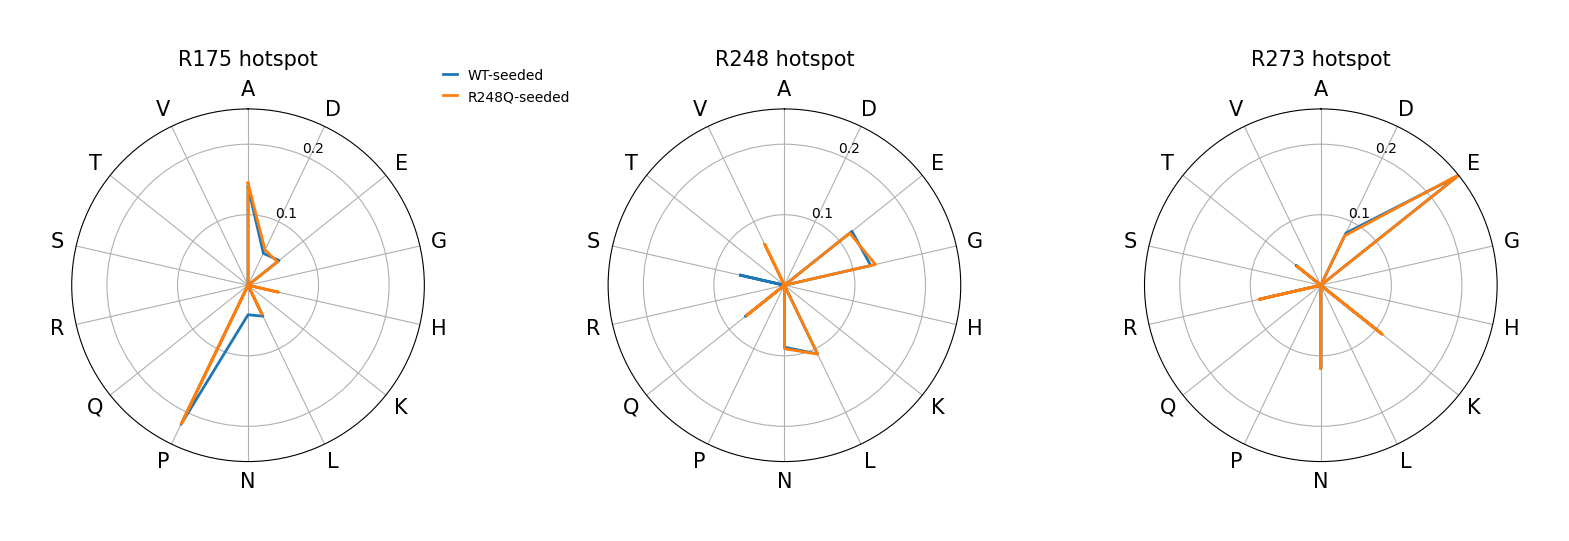

In [7]:
fig, axes = plt.subplots(
    1,
    len(positions),
    figsize=(5 * len(positions), 5),
    subplot_kw={"polar": True},
)

amino_acids = "ACDEFGHIKLMNPQRSTVWY"

# Then derive the shared candidate amino-acid labels from the union of all observed residues.
observed_amino_acids = {
    aa
    for data in position_freqs.values()
    for aa in [*data["wt"].index.tolist(), *data["mut"].index.tolist()]
}
candidate_amino_acids = [aa for aa in amino_acids if aa in observed_amino_acids]

angles = np.linspace(0, 2 * np.pi, len(candidate_amino_acids), endpoint=False).tolist()
angles += angles[:1]

for ax, (label, pos) in zip(axes, positions.items()):
    wt_freq = position_freqs[label]["wt"]
    mut_freq = position_freqs[label]["mut"]

    wt_values = [wt_freq.get(aa, 0.0) for aa in candidate_amino_acids] + [wt_freq.get(candidate_amino_acids[0], 0.0)]
    mut_values = [mut_freq.get(aa, 0.0) for aa in candidate_amino_acids] + [mut_freq.get(candidate_amino_acids[0], 0.0)]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(candidate_amino_acids, fontsize=15)
    ax.set_ylim(0, 0.25) # empirical 
    ax.set_yticks([0.1, 0.2])

    ax.plot(angles, wt_values, color="tab:blue", linewidth=2, linestyle="-", label="WT-seeded")
    ax.plot(angles, mut_values, color="tab:orange", linewidth=2, linestyle="-", label="R248Q-seeded")
    ax.set_title(f"{label}", y=1.1, fontsize=15)

axes[0].legend(loc="upper right", bbox_to_anchor=(1.45, 1.15), frameon=False)
plt.tight_layout()
plt.show()

And there we have it. It looks like the WT-seeded MSA aligns a few more Asparagines at position 175 and Serines at 248 compared to the R248Q-seeded one. 

That's it for this example!